In [37]:
# Importando bibliotecas

import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt

In [30]:
# Carregando o arquivo query02.csv

df = pd.read_csv('query02.csv')

display(df.head(50))

,FIRST_NAME,SALARY,DEPARTMENT_NAME,STREET_ADDRESS,STATE_PROVINCE,COUNTRY_NAME,REGION_NAME
0,Steven,24000,Executive,2004 Charade Rd,Washington,United States of America,Americas
1,Neena,17000,Executive,2004 Charade Rd,Washington,United States of America,Americas
2,Lex,17000,Executive,2004 Charade Rd,Washington,United States of America,Americas
3,Alexander,9000,IT,2014 Jabberwocky Rd,Texas,United States of America,Americas
4,Bruce,6000,IT,2014 Jabberwocky Rd,Texas,United States of America,Americas
5,David,4800,IT,2014 Jabberwocky Rd,Texas,United States of America,Americas
6,Valli,4800,IT,2014 Jabberwocky Rd,Texas,United States of America,Americas
7,Diana,4200,IT,2014 Jabberwocky Rd,Texas,United States of America,Americas
8,Nancy,12008,Finance,2004 Charade Rd,Washington,United States of America,Americas
9,Daniel,9000,Finance,2004 Charade Rd,Washington,United States of America,Americas


In [31]:
# Fazendo uma análise inicial do DataFrame 02

display(f"Número de registros: {df.shape[0]}")
display(f"Número de colunas: {df.shape[1]}")
display(f"Tipos de informação da coluna: {df.dtypes}")
display(f"Valores nulos nas colunas: {df.isnull().sum()}")
display(f"Valores duplicados nas colunas: {df.duplicated().sum()}")

'Número de registros: 106'

'Número de colunas: 7'

'Tipos de informação da coluna: FIRST_NAME           str\nSALARY             int64\nDEPARTMENT_NAME      str\nSTREET_ADDRESS       str\nSTATE_PROVINCE       str\nCOUNTRY_NAME         str\nREGION_NAME          str\ndtype: object'

'Valores nulos nas colunas: FIRST_NAME         0\nSALARY             0\nDEPARTMENT_NAME    0\nSTREET_ADDRESS     0\nSTATE_PROVINCE     1\nCOUNTRY_NAME       0\nREGION_NAME        0\ndtype: int64'

'Valores duplicados nas colunas: 0'

Foi encontrado um valor nulo na tabela STATE_PROVINCE, que será analisado mais profundamente adiante.

In [29]:
#identificando linhas duplicadas

display(df[df.duplicated(keep=False)])

,FIRST_NAME,SALARY,DEPARTMENT_NAME,STREET_ADDRESS,STATE_PROVINCE,COUNTRY_NAME,REGION_NAME


In [34]:
# Verificando os valores presentes na coluna STATE_PROVINCE

display(f"STATE_PROVINCE: {df['STATE_PROVINCE'].unique()}")
display(df[df["STATE_PROVINCE"].isna()])

display(df[df['COUNTRY_NAME'] == 'United Kingdom of Great Britain and Northern Ireland'])

"STATE_PROVINCE: <StringArray>\n['Washington', 'Texas', 'California', 'Oxford', 'Ontario', nan, 'Bavaria']\nLength: 7, dtype: str"

,FIRST_NAME,SALARY,DEPARTMENT_NAME,STREET_ADDRESS,STATE_PROVINCE,COUNTRY_NAME,REGION_NAME
102,Susan,6500,Human Resources,8204 Arthur St,NaN,United Kingdom of Great Britain and Northern I...,Europe


,FIRST_NAME,SALARY,DEPARTMENT_NAME,STREET_ADDRESS,STATE_PROVINCE,COUNTRY_NAME,REGION_NAME
45,John,14000,Sales,"Magdalen Centre, The Oxford Science Park",Oxford,United Kingdom of Great Britain and Northern I...,Europe
46,Karen,13500,Sales,"Magdalen Centre, The Oxford Science Park",Oxford,United Kingdom of Great Britain and Northern I...,Europe
47,Alberto,12000,Sales,"Magdalen Centre, The Oxford Science Park",Oxford,United Kingdom of Great Britain and Northern I...,Europe
48,Gerald,11000,Sales,"Magdalen Centre, The Oxford Science Park",Oxford,United Kingdom of Great Britain and Northern I...,Europe
49,Eleni,10500,Sales,"Magdalen Centre, The Oxford Science Park",Oxford,United Kingdom of Great Britain and Northern I...,Europe
50,Sean,10000,Sales,"Magdalen Centre, The Oxford Science Park",Oxford,United Kingdom of Great Britain and Northern I...,Europe
51,David,9500,Sales,"Magdalen Centre, The Oxford Science Park",Oxford,United Kingdom of Great Britain and Northern I...,Europe
52,Peter,9000,Sales,"Magdalen Centre, The Oxford Science Park",Oxford,United Kingdom of Great Britain and Northern I...,Europe
53,Christopher,8000,Sales,"Magdalen Centre, The Oxford Science Park",Oxford,United Kingdom of Great Britain and Northern I...,Europe
54,Nanette,7500,Sales,"Magdalen Centre, The Oxford Science Park",Oxford,United Kingdom of Great Britain and Northern I...,Europe


Após uma análise mais profunda, foi constatado que o registro da funcionária Susan não possui nenhuma informação na tabela STATE_PROVINCE, sugiro que o departamento de recursos humanos atualize o cadastro da mesma.

In [36]:
# verificando o tamanho do DataFrame, tipos de informação das colunas, quantidade de valores nulos, após a limpeza dos dados

display(f'Tamanho do DataFrame: {df.shape}')
display(f'Tipos de informação das colunas: {df.dtypes.unique()}')
display(f'Quantidade de valores nulos: {df.isnull().sum().sum()}')
display(f'Quantidade de valores duplicados: {df.duplicated().sum()}')

'Tamanho do DataFrame: (106, 7)'

"Tipos de informação das colunas: [<StringDtype(storage='python', na_value=nan)> dtype('int64')]"

'Quantidade de valores nulos: 1'

'Quantidade de valores duplicados: 0'

Número de colaboradores por país:

In [ ]:
Colaboradores = (
    df[["FIRST_NAME", "DEPARTMENT_NAME", "COUNTRY_NAME"]].sort_values("COUNTRY_NAME", ascending=False)
)
numero_de_colaboradores = Colaboradores.groupby("COUNTRY_NAME")["FIRST_NAME"].count()

print(f"Número de colaboradores:\n{numero_de_colaboradores}")

Número de colaboradores:
COUNTRY_NAME
Canada                                                   2
Germany                                                  1
United Kingdom of Great Britain and Northern Ireland    35
United States of America                                68
Name: FIRST_NAME, dtype: int64


Analisando informações salariais de colaboradores por país

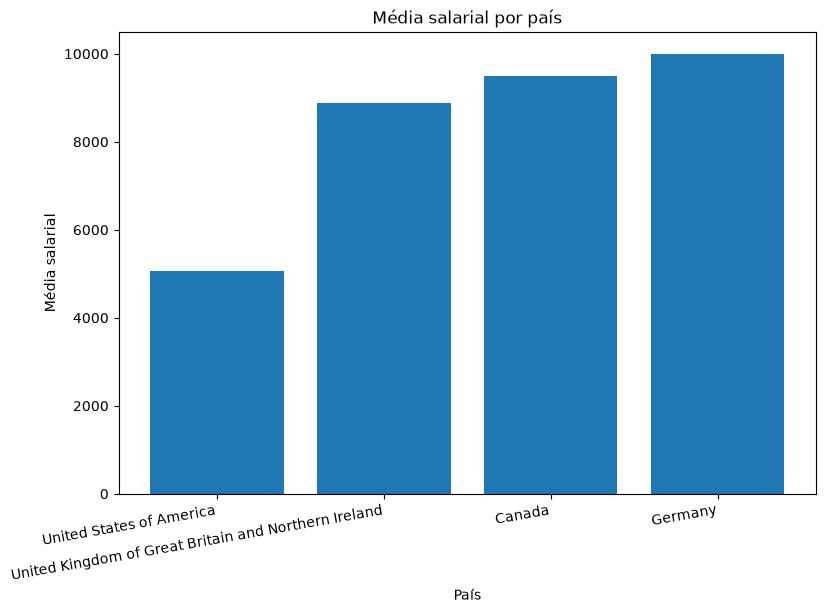

In [94]:
media_pais = (
    df
    .groupby("COUNTRY_NAME")["SALARY"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(9, 6))

plt.bar(
    media_pais.index,
    media_pais.values
)

plt.title("Média salarial por país")
plt.xlabel("País")
plt.ylabel("Média salarial")

plt.xticks(
    rotation=10,
    ha="right"
)

plt.show()

In [89]:
Colaboradores = (
    df[["SALARY", "DEPARTMENT_NAME", "COUNTRY_NAME"]].sort_values("COUNTRY_NAME", ascending=False)
)
colaboradores = Colaboradores.groupby(["COUNTRY_NAME", "DEPARTMENT_NAME"]).count()

print(f"colaboradores por país:\n{colaboradores}")

colaboradores por país:
                                                                     SALARY
COUNTRY_NAME                                       DEPARTMENT_NAME         
Canada                                             Marketing              2
Germany                                            Public Relations       1
United Kingdom of Great Britain and Northern Ir... Human Resources        1
                                                   Sales                 34
United States of America                           Accounting             2
                                                   Administration         1
                                                   Executive              3
                                                   Finance                6
                                                   IT                     5
                                                   Purchasing             6
                                                   Shipping     

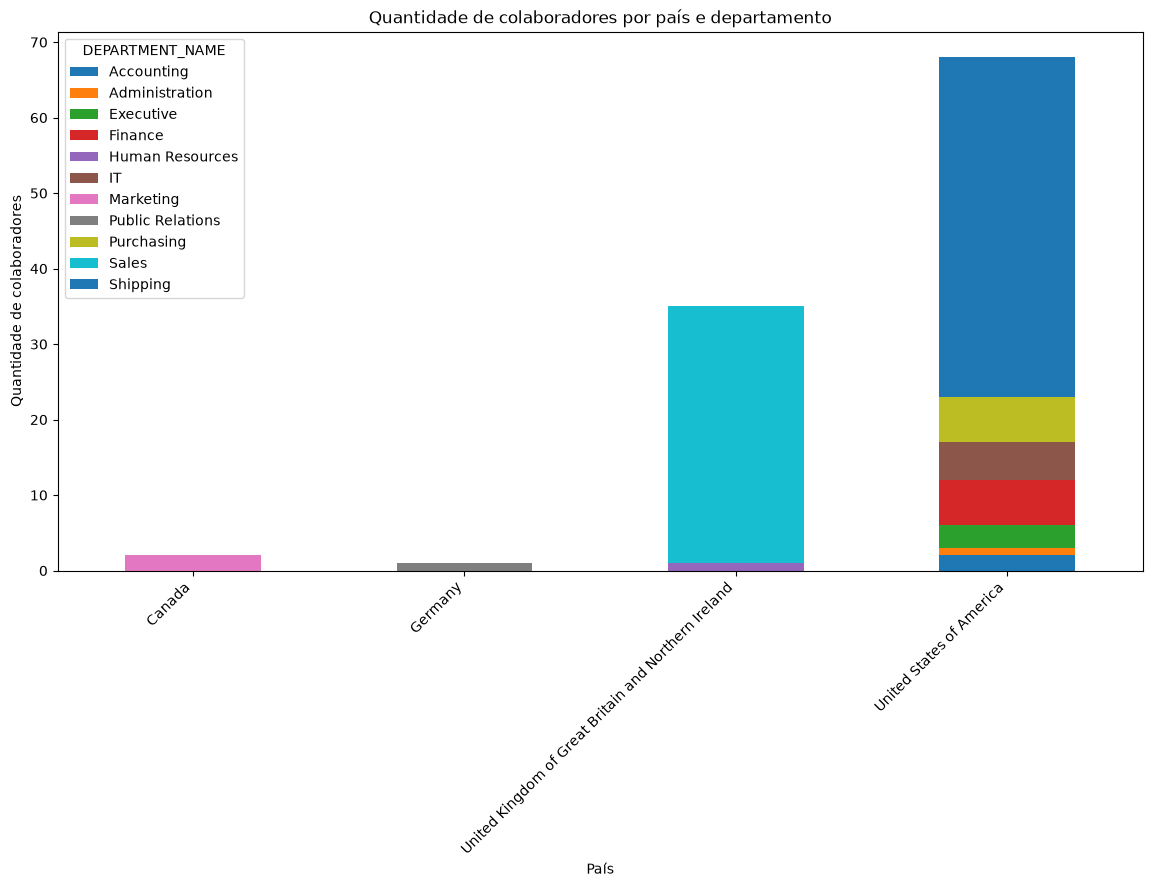

In [88]:

colaboradores = (
    Colaboradores.groupby(["COUNTRY_NAME", "DEPARTMENT_NAME"]).size().unstack(fill_value=0))

ax = colaboradores.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Quantidade de colaboradores por país e departamento")
plt.xlabel("País")
plt.ylabel("Quantidade de colaboradores")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.show()

Um detalhe interessante que podemos observar é que a maioria dos vendedores da empresa, estão concentrados no reino unido, enquanto a maioria dos colaboradores do shipping se concentra nos Estados Unidos, o que explica também o por que a média salarial dos colaboradores americanos é mais baixa.

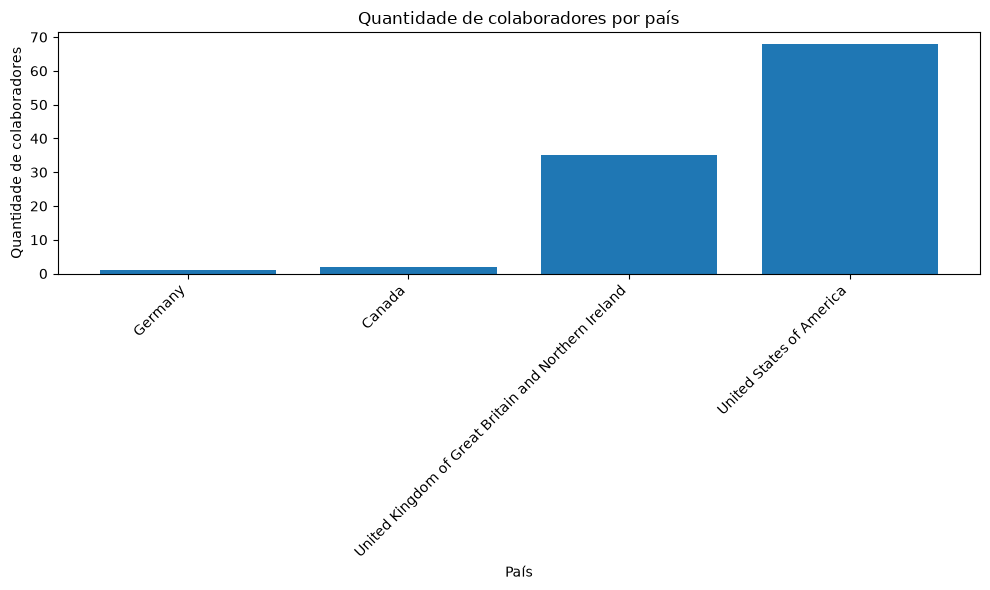

In [84]:

colaboradores_pais = (
    Colaboradores.groupby("COUNTRY_NAME")["DEPARTMENT_NAME"].count().sort_values())

plt.figure(figsize=(10, 6))

plt.bar(
    colaboradores_pais.index,
    colaboradores_pais.values
)

plt.title("Quantidade de colaboradores por país")
plt.xlabel("País")
plt.ylabel("Quantidade de colaboradores")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

A maior concentração de colaboradores da empresa está nos Estados Unidos com 68 colaboradores, seguido pelo Reino Unido com 35, enquanto Canadá e Alemanha possuem 2 e 1 colaboradores, respectivamente.